In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
weather_data = pd.read_csv("../data/clean/weather_clean.csv")

In [3]:
weather_data.head()


,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,showers_sum,wind_speed_10m_max,wind_gusts_10m_max,relative_humidity_2m_mean,cloud_cover_mean,sunshine_duration,shortwave_radiation_sum,city,month,year,season
0,2020-01-01,5.2,-1.0,2.8,0.6,0.6,0.0,12.2,22.7,97,99,0.00,1.57,Paris,1,2020,winter
1,2020-01-02,9.2,4.7,7.2,1.5,1.5,0.0,18.8,31.3,94,94,12730.83,2.36,Paris,1,2020,winter
2,2020-01-03,11.5,7.9,9.7,0.9,0.9,0.0,24.4,41.4,88,94,13199.25,2.18,Paris,1,2020,winter
3,2020-01-04,8.6,2.6,5.8,0.0,0.0,0.0,16.3,29.9,87,71,21947.97,4.16,Paris,1,2020,winter
4,2020-01-05,8.9,2.3,5.3,0.0,0.0,0.0,7.6,11.5,92,51,28800.00,3.69,Paris,1,2020,winter


In [4]:
weather_data["time"] = pd.to_datetime(weather_data["time"])

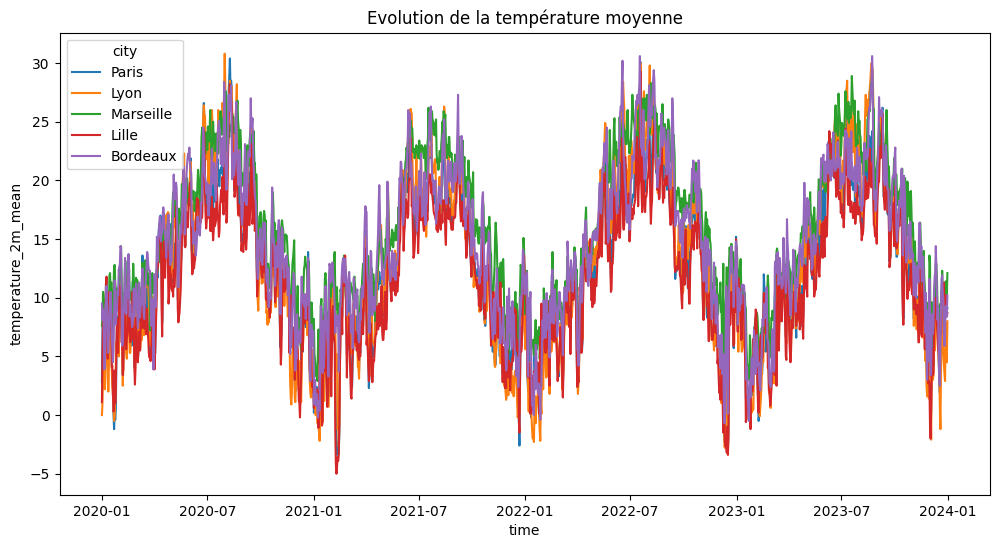

In [5]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=weather_data,
    x="time",
    y="temperature_2m_mean",
    hue="city"
)

plt.title("Evolution de la température moyenne")
plt.show()

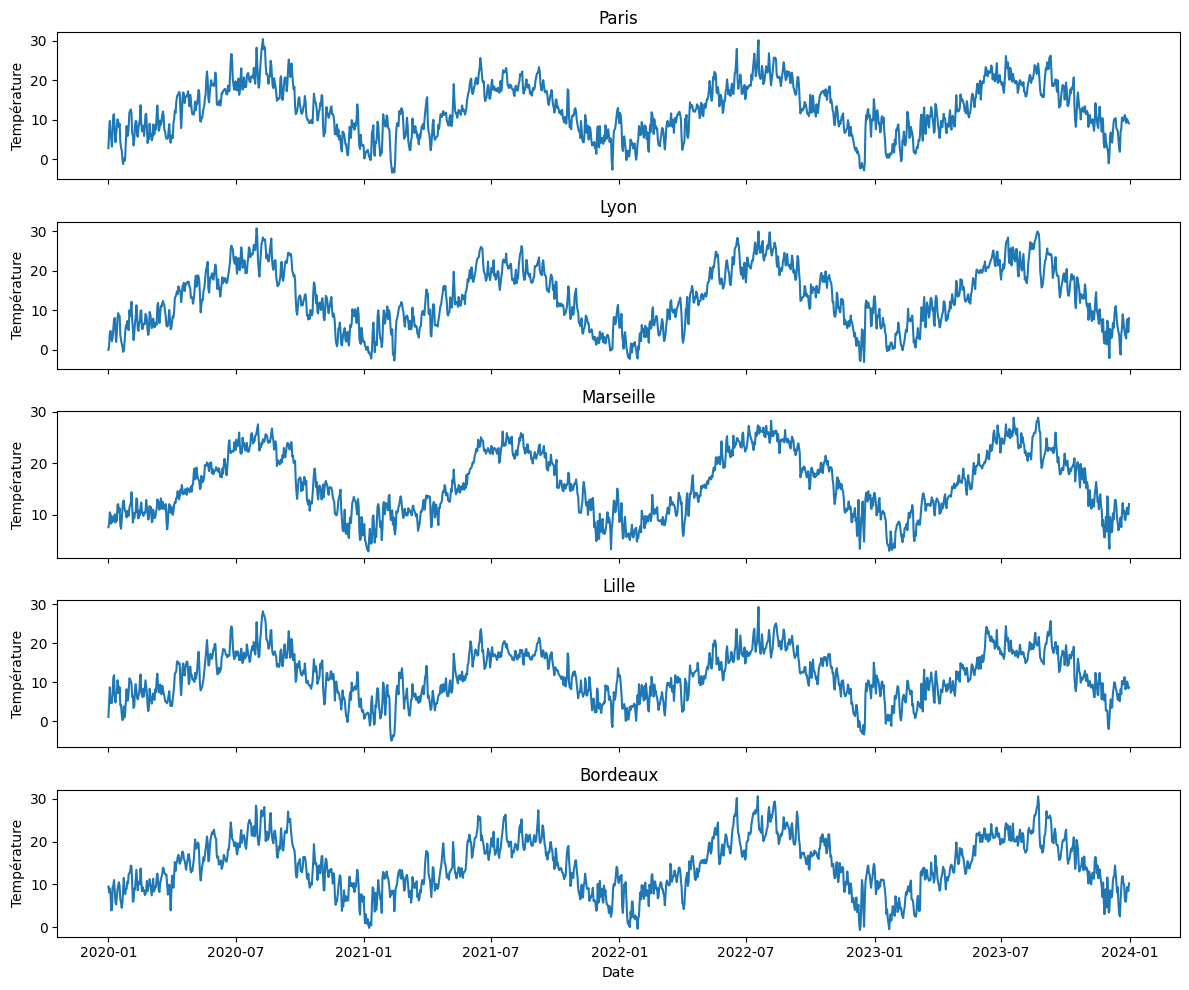

In [6]:
cities = weather_data["city"].unique()

fig, axes = plt.subplots(len(cities), 1, figsize=(12,10), sharex=True)

for i, city in enumerate(cities):
    
    city_data = weather_data[weather_data["city"] == city]
    
    axes[i].plot(city_data["time"], city_data["temperature_2m_mean"])
    axes[i].set_title(city)
    axes[i].set_ylabel("Température")

plt.xlabel("Date")
plt.tight_layout()
plt.show()

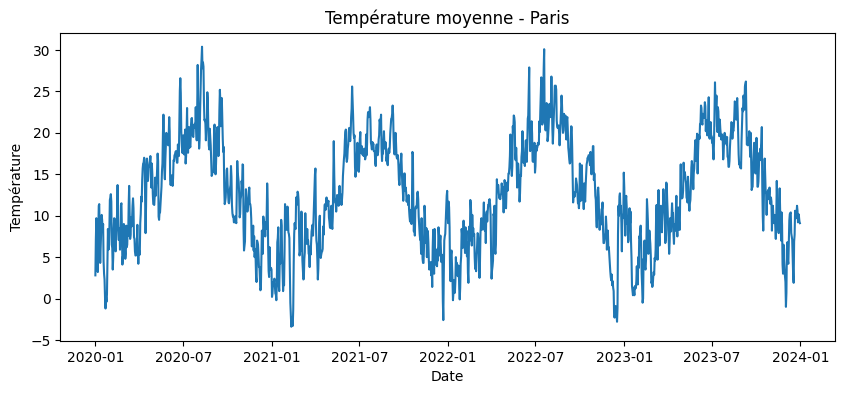

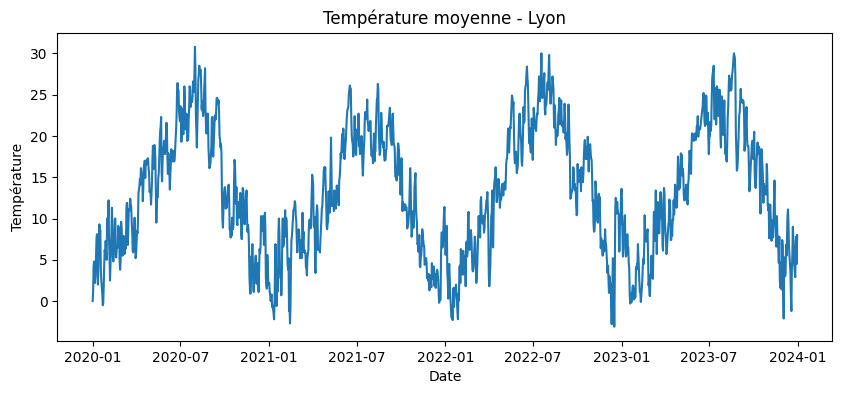

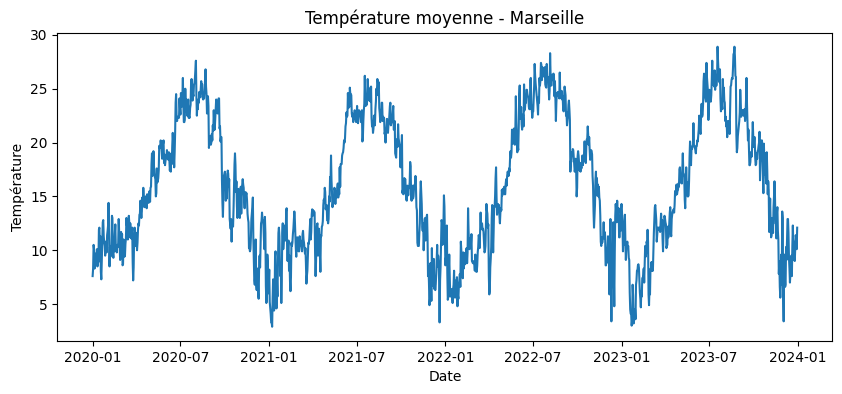

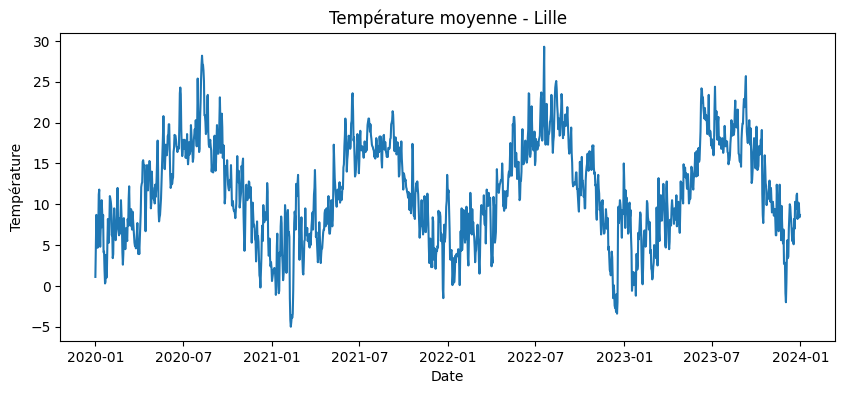

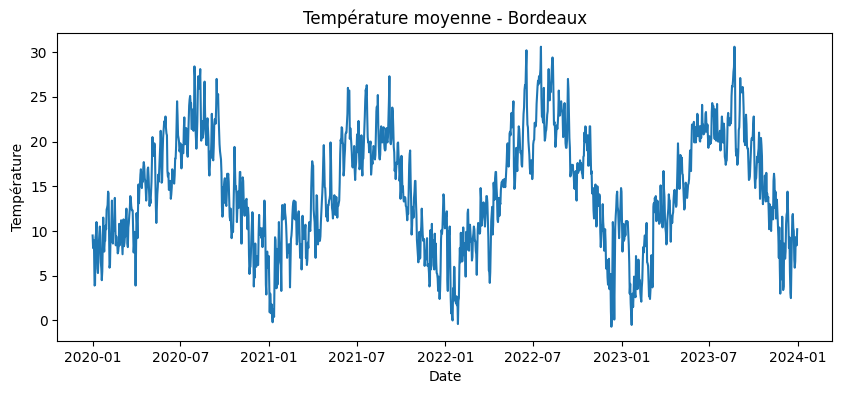

In [7]:
cities = weather_data["city"].unique()

for city in cities:
    
    city_data = weather_data[weather_data["city"] == city]
    
    plt.figure(figsize=(10,4))
    
    plt.plot(city_data["time"], city_data["temperature_2m_mean"])
    
    plt.title(f"Température moyenne - {city}")
    plt.xlabel("Date")
    plt.ylabel("Température")
    
    plt.show()

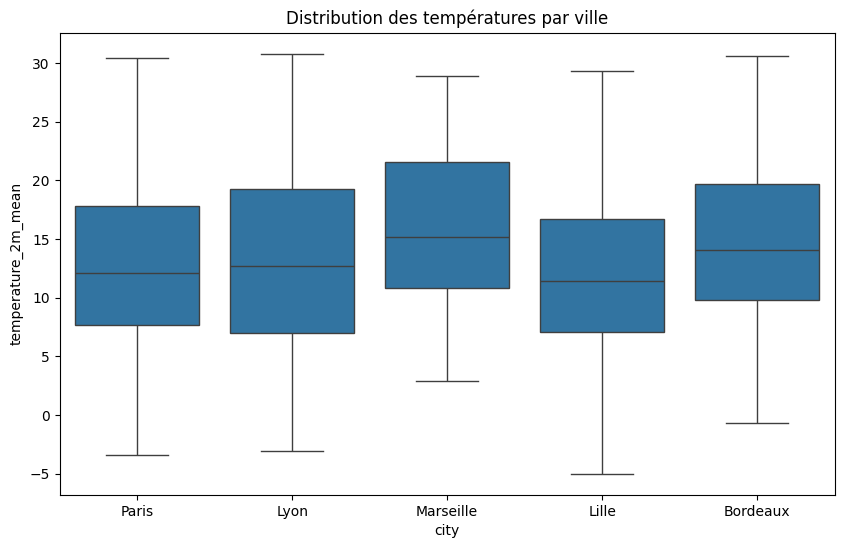

In [8]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=weather_data,
    x="city",
    y="temperature_2m_mean"
)

plt.title("Distribution des températures par ville")
plt.show()

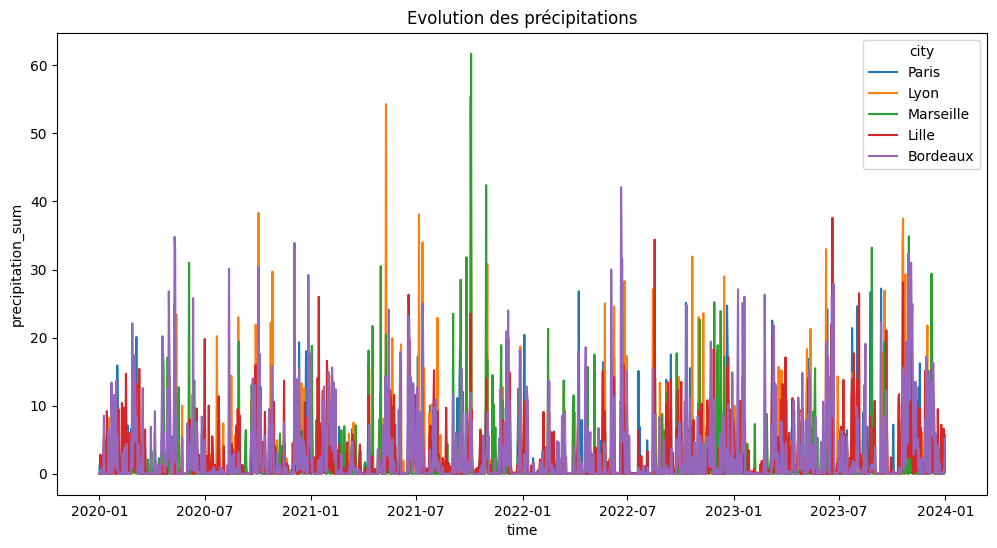

In [9]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=weather_data,
    x="time",
    y="precipitation_sum",
    hue="city"
)

plt.title("Evolution des précipitations")
plt.show()

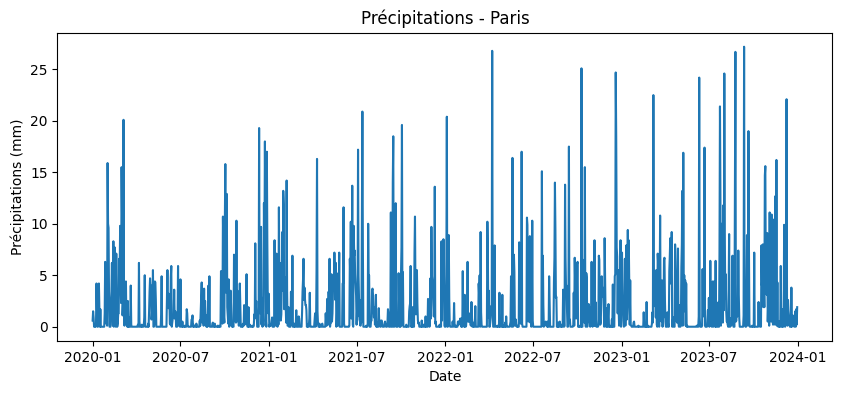

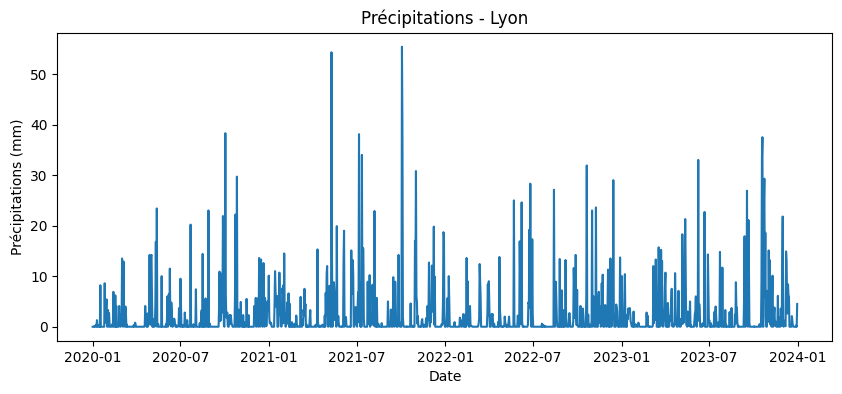

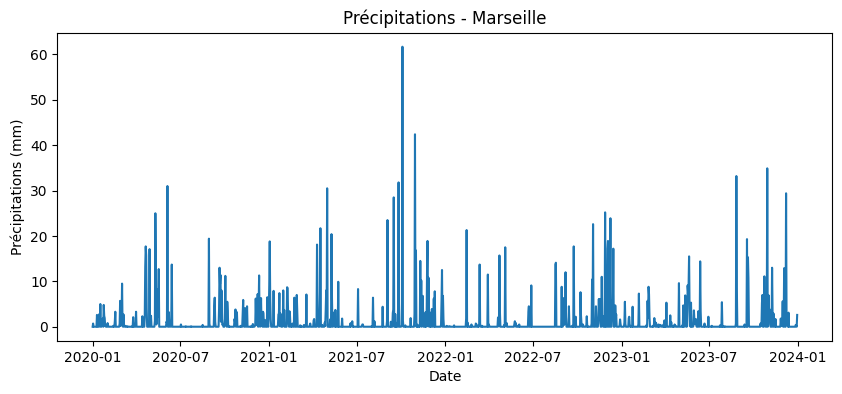

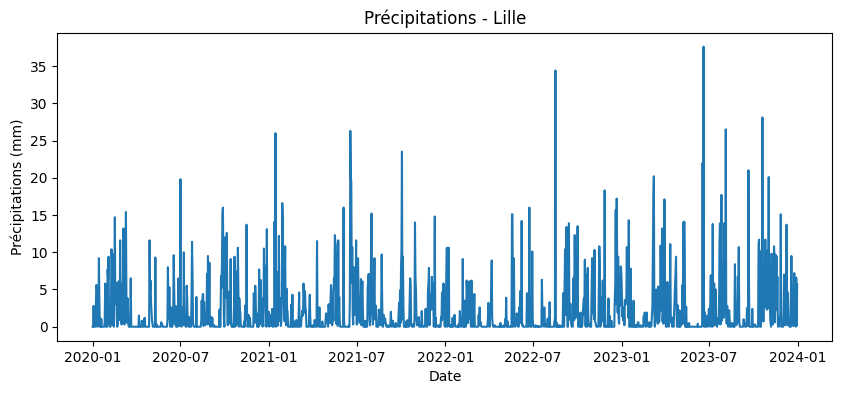

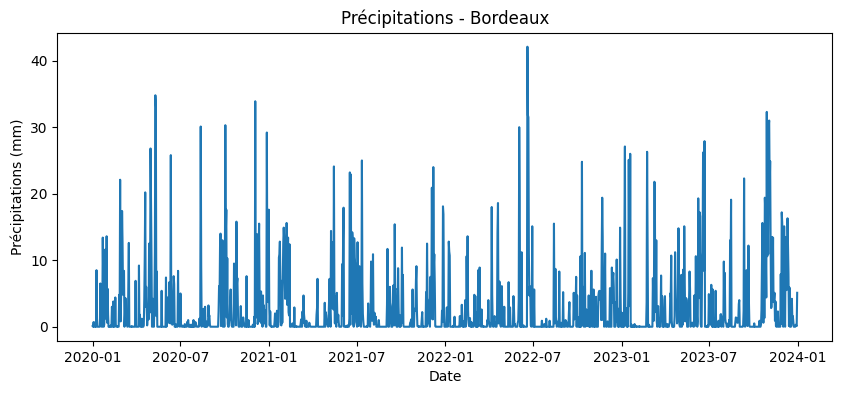

In [11]:
cities = weather_data["city"].unique()

for city in cities:

    city_data = weather_data[weather_data["city"] == city]

    plt.figure(figsize=(10,4))

    plt.plot(city_data["time"], city_data["precipitation_sum"])

    plt.title(f"Précipitations - {city}")
    plt.xlabel("Date")
    plt.ylabel("Précipitations (mm)")

    plt.show()

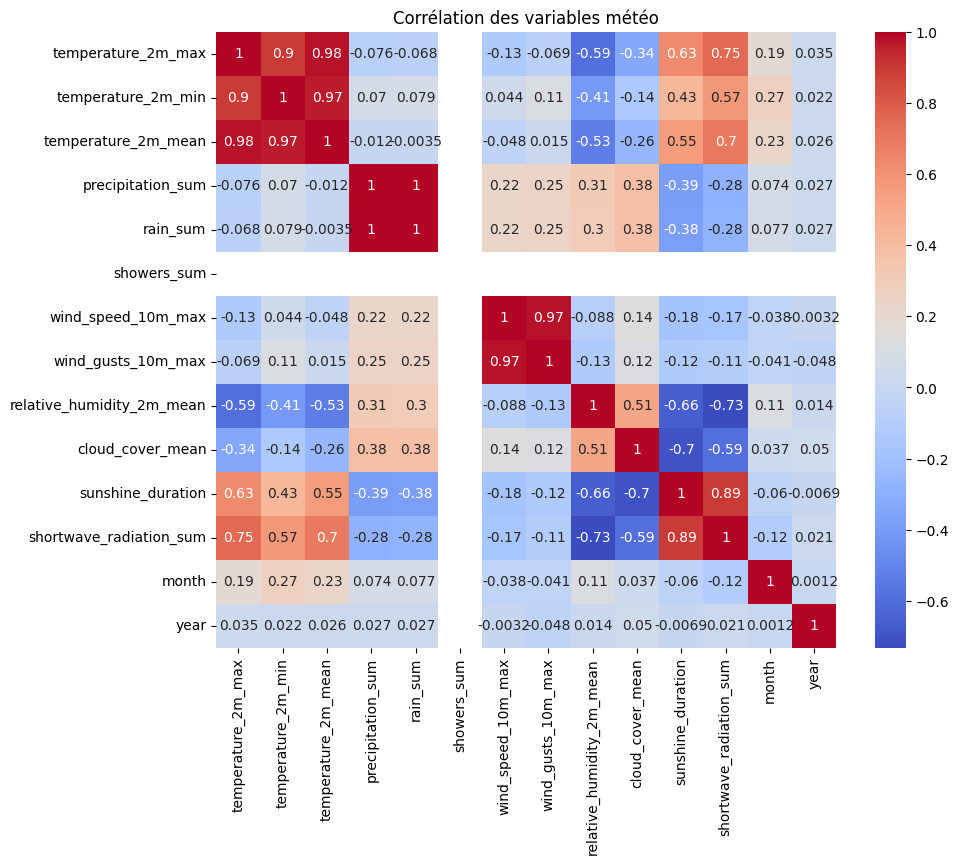

In [12]:
plt.figure(figsize=(10,8))

corr = weather_data.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Corrélation des variables météo")
plt.show()

La heatmap de corrélation met en évidence plusieurs relations importantes entre les variables météorologiques du dataset. Tout d’abord, les variables de température (`temperature_2m_max`, `temperature_2m_min` et `temperature_2m_mean`) présentent une très forte corrélation entre elles, avec des valeurs proches de 1. Cela signifie qu’elles évoluent quasiment de la même manière et qu’elles mesurent en réalité le même phénomène sous différentes formes. De la même manière, les variables liées aux précipitations (`precipitation_sum` et `rain_sum`) sont parfaitement corrélées, ce qui indique qu’elles représentent pratiquement la même information dans ce dataset. On observe également une forte corrélation positive entre la durée d’ensoleillement (`sunshine_duration`) et le rayonnement solaire (`shortwave_radiation_sum`), ce qui est logique puisque ces deux variables décrivent l’énergie solaire reçue. À l’inverse, ces variables sont négativement corrélées avec les précipitations et la couverture nuageuse, ce qui confirme que les périodes pluvieuses sont généralement associées à moins d’ensoleillement. Par ailleurs, l’humidité relative (`relative_humidity_2m_mean`) est modérément corrélée avec la couverture nuageuse (`cloud_cover_mean`), ce qui reflète le fait que l’air humide favorise la formation de nuages. Enfin, la vitesse maximale du vent et les rafales (`wind_speed_10m_max` et `wind_gusts_10m_max`) sont très fortement corrélées, ce qui est cohérent puisque les rafales sont liées à l’intensité du vent. Globalement, cette analyse montre que les données météorologiques sont cohérentes et qu’elles contiennent des relations logiques entre les variables, ce qui les rend pertinentes pour des analyses climatiques et pour la construction de modèles de prédiction d’événements météorologiques extrêmes, comme les conditions favorables aux orages ou à la grêle.


In [13]:
weather_data["hail_risk"] = (
    (weather_data["precipitation_sum"] > 15) &
    (weather_data["wind_gusts_10m_max"] > 60) &
    (weather_data["relative_humidity_2m_mean"] > 80)
).astype(int)

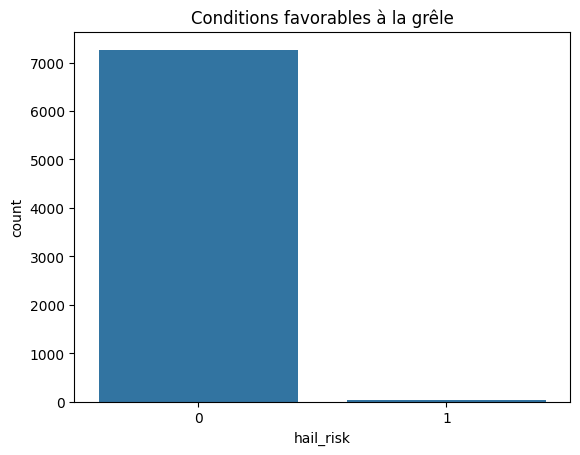

In [14]:
sns.countplot(data=weather_data, x="hail_risk")

plt.title("Conditions favorables à la grêle")
plt.show()

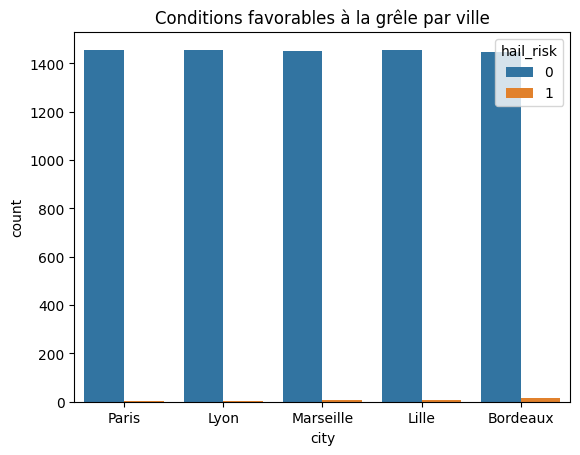

In [15]:
sns.countplot(data=weather_data, x="city", hue="hail_risk")

plt.title("Conditions favorables à la grêle par ville")
plt.show()

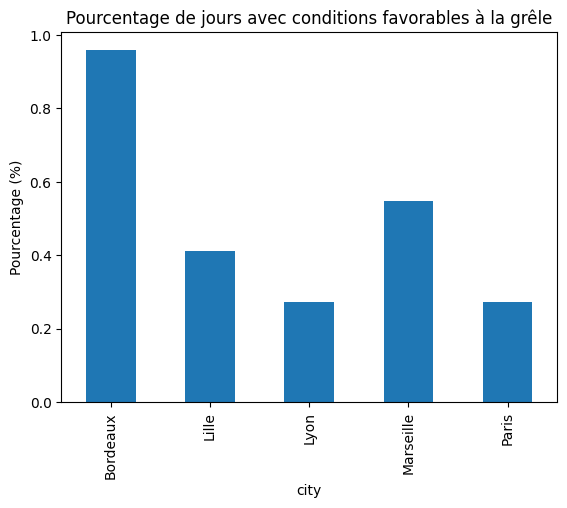

In [16]:
hail_by_city = (
    weather_data
    .groupby("city")["hail_risk"]
    .mean()
    * 100
)

hail_by_city.plot(kind="bar")

plt.title("Pourcentage de jours avec conditions favorables à la grêle")
plt.ylabel("Pourcentage (%)")
plt.show()

In [17]:
weather_data["month"] = weather_data["time"].dt.month

In [18]:
hail_month = (
    weather_data
    .groupby(["city", "month"])["hail_risk"]
    .mean()
    * 100
).reset_index()

In [19]:
hail_pivot = hail_month.pivot(index="city", columns="month", values="hail_risk")

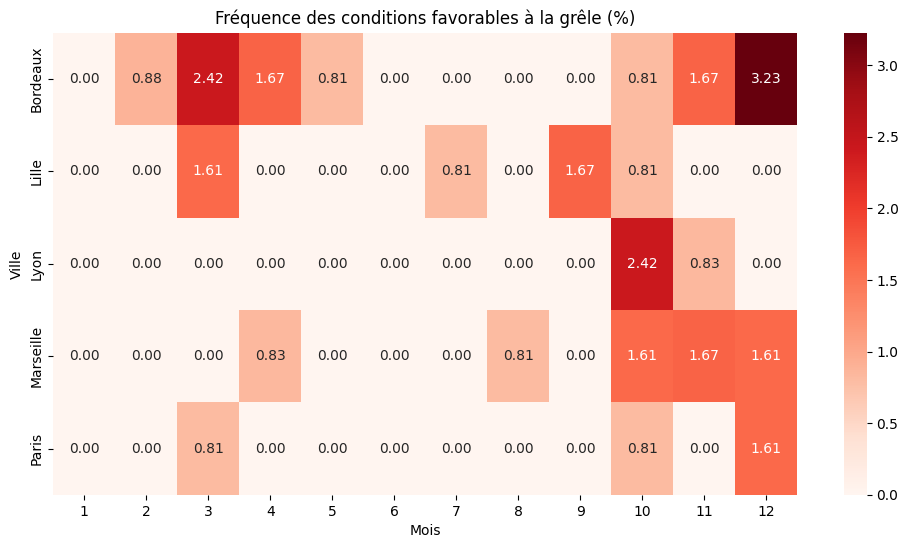

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(
    hail_pivot,
    cmap="Reds",
    annot=True,
    fmt=".2f"
)

plt.title("Fréquence des conditions favorables à la grêle (%)")
plt.xlabel("Mois")
plt.ylabel("Ville")

plt.show()

La heatmap représentant la fréquence des conditions favorables à la grêle par mois et par ville permet de mettre en évidence la saisonnalité des phénomènes météorologiques extrêmes. On observe que les conditions propices à la grêle restent globalement rares dans l’ensemble du dataset, avec des pourcentages généralement faibles, ce qui est cohérent avec la nature exceptionnelle de ce type d’événement. Cependant, certaines périodes de l’année présentent une fréquence légèrement plus élevée. Par exemple, la ville de Bordeaux montre des valeurs plus importantes au printemps et en fin d’année, avec un pic notable en décembre. De son côté, Lille présente quelques occurrences au début du printemps et à l’automne, tandis que Lyon et Marseille enregistrent principalement des conditions favorables durant l’automne. Paris montre également quelques occurrences isolées sur certaines périodes de l’année. Globalement, cette visualisation met en évidence que les conditions favorables à la grêle apparaissent de manière sporadique et varient selon les villes et les saisons. Cette analyse confirme l’importance de certains facteurs météorologiques comme les précipitations, l’humidité et les rafales de vent dans l’apparition de conditions propices aux orages violents, et montre que ces phénomènes restent relativement rares mais distribués de manière saisonnière selon les régions étudiées.


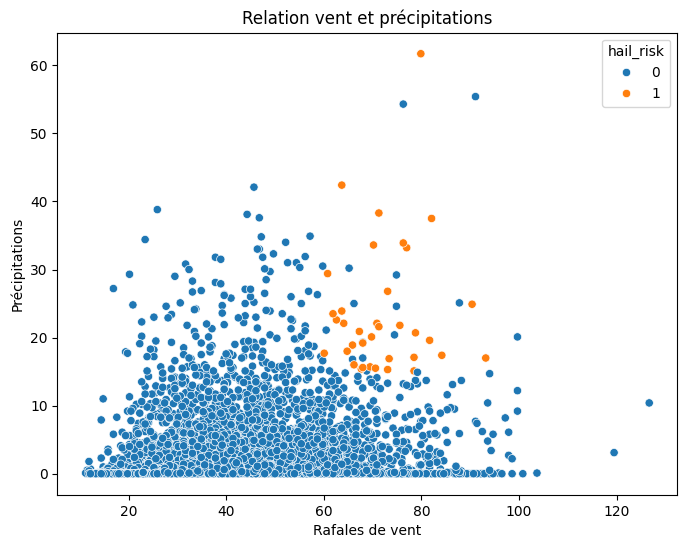

In [21]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=weather_data,
    x="wind_gusts_10m_max",
    y="precipitation_sum",
    hue="hail_risk"
)

plt.title("Relation vent et précipitations")
plt.xlabel("Rafales de vent")
plt.ylabel("Précipitations")
plt.show()

fortes rafales + forte pluie = orage violent

zone de risque de grêle

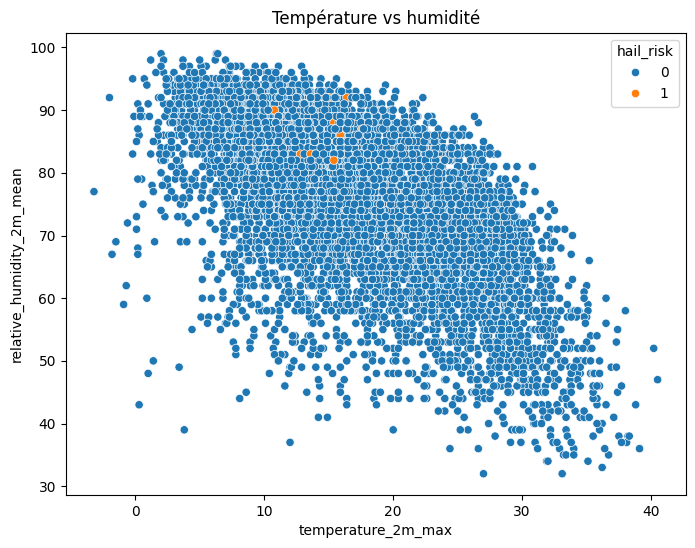

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=weather_data,
    x="temperature_2m_max",
    y="relative_humidity_2m_mean",
    hue="hail_risk"
)

plt.title("Température vs humidité")
plt.show()


conditions atmosphériques instables

formation d’orages

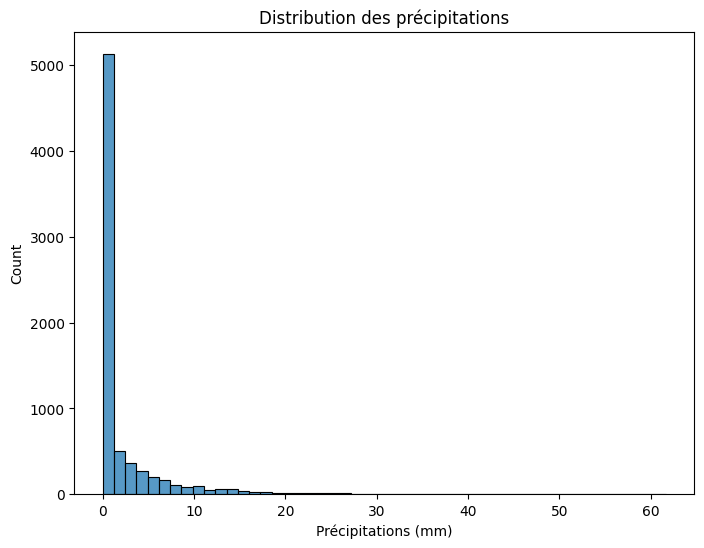

In [23]:
plt.figure(figsize=(8,6))

sns.histplot(
    weather_data["precipitation_sum"],
    bins=50
)

plt.title("Distribution des précipitations")
plt.xlabel("Précipitations (mm)")
plt.show()

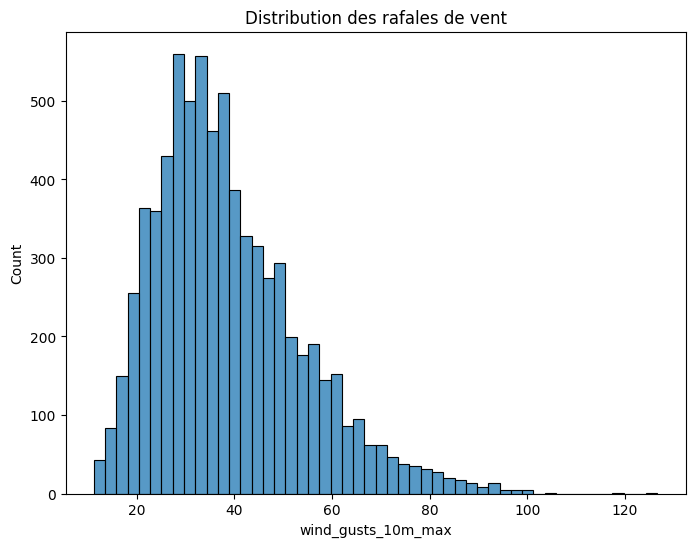

In [24]:
plt.figure(figsize=(8,6))

sns.histplot(
    weather_data["wind_gusts_10m_max"],
    bins=50
)

plt.title("Distribution des rafales de vent")
plt.show()

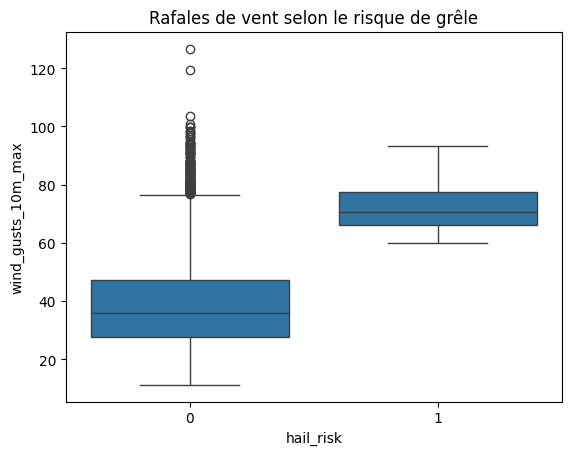

In [25]:
sns.boxplot(
    data=weather_data,
    x="hail_risk",
    y="wind_gusts_10m_max"
)

plt.title("Rafales de vent selon le risque de grêle")
plt.show()

Le boxplot représentant les rafales de vent maximales (wind_gusts_10m_max) en fonction du risque de grêle (hail_risk) met en évidence une différence notable entre les deux situations. Lorsque hail_risk = 0, c’est-à-dire lorsque les conditions ne sont pas favorables à la grêle, les rafales de vent restent globalement plus faibles, avec une médiane située autour de 30 à 35 km/h. On observe cependant quelques valeurs extrêmes plus élevées, indiquant que certaines journées peuvent présenter de fortes rafales sans pour autant réunir toutes les conditions nécessaires à la formation de grêle. En revanche, lorsque hail_risk = 1, les rafales de vent sont nettement plus importantes, avec une médiane située autour de 70 km/h et une distribution globalement plus élevée. Cela signifie que les jours où les conditions sont favorables à la grêle sont généralement associés à des vents beaucoup plus forts. Cette observation est cohérente avec les phénomènes météorologiques liés aux orages violents, qui s’accompagnent souvent de fortes rafales dues aux mouvements convectifs dans l’atmosphère. Ainsi, ce graphique suggère que la vitesse des rafales de vent constitue un indicateur pertinent pour identifier ou prédire des épisodes d’intempéries sévères, notamment ceux pouvant conduire à la formation de grêle.

Quand il y a un risque de grêle (hail_risk = 1), les rafales de vent sont beaucoup plus fortes.

On voit que :

sans risque de grêle → vent autour de 30-40 km/h

avec risque de grêle → vent autour de 65-75 km/h

Donc :

✅ les épisodes de grêle sont souvent associés à des rafales de vent plus intenses, ce qui correspond aux orages violents.

In [26]:
hail_days = weather_data[weather_data["hail_risk"] == 1]

hail_days[[
    "time",
    "city",
    "temperature_2m_max",
    "precipitation_sum",
    "wind_gusts_10m_max",
    "relative_humidity_2m_mean"
]].head(20)

,time,city,temperature_2m_max,precipitation_sum,wind_gusts_10m_max,relative_humidity_2m_mean
64,2020-03-05,Paris,12.6,20.1,69.8,90
361,2020-12-27,Paris,8.1,17.0,93.2,87
641,2021-10-03,Paris,18.0,19.6,81.7,81
1438,2023-12-09,Paris,14.1,22.1,64.1,89
1736,2020-10-02,Lyon,17.0,38.3,71.3,86
2848,2023-10-19,Lyon,19.7,33.6,70.2,86
2849,2023-10-20,Lyon,18.4,37.5,82.1,83
2862,2023-11-02,Lyon,13.4,15.1,78.5,81
3564,2021-10-04,Marseille,19.2,61.7,79.9,90
3590,2021-10-30,Marseille,17.0,42.4,63.7,88


In [27]:
hail_days = hail_days.sort_values("wind_gusts_10m_max", ascending=False)

hail_days.head(20)

,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,rain_sum,showers_sum,wind_speed_10m_max,wind_gusts_10m_max,relative_humidity_2m_mean,cloud_cover_mean,sunshine_duration,shortwave_radiation_sum,city,month,year,season,hail_risk
361,2020-12-27,8.1,4.1,6.2,17.0,17.0,0.0,45.2,93.2,87,90,0.00,0.68,Paris,12,2020,winter,1
7248,2023-11-05,13.8,10.5,12.2,24.9,24.9,0.0,44.0,90.4,86,86,22837.45,5.69,Bordeaux,11,2023,autumn,1
5905,2020-03-02,10.8,6.6,8.7,17.4,17.4,0.0,38.8,84.2,82,71,30709.86,11.55,Bordeaux,3,2020,spring,1
2849,2023-10-20,18.4,14.6,16.4,37.5,37.5,0.0,38.9,82.1,83,86,16036.18,5.66,Lyon,10,2023,autumn,1
641,2021-10-03,18.0,11.9,15.1,19.6,19.6,0.0,34.8,81.7,81,92,3247.66,4.21,Paris,10,2021,autumn,1
3564,2021-10-04,19.2,12.9,15.3,61.7,61.7,0.0,42.6,79.9,90,97,2828.23,4.27,Marseille,10,2021,autumn,1
7247,2023-11-04,15.4,10.3,13.0,20.7,20.7,0.0,42.9,78.8,82,88,6582.19,2.17,Bordeaux,11,2023,autumn,1
5568,2023-03-31,11.2,9.1,10.3,17.1,17.1,0.0,43.8,78.5,87,100,0.00,3.01,Lille,3,2023,spring,1
2862,2023-11-02,13.4,8.1,11.7,15.1,15.1,0.0,41.8,78.5,81,98,7344.12,3.51,Lyon,11,2023,autumn,1
4256,2023-08-27,23.5,19.4,20.7,33.2,33.2,0.0,43.5,77.0,82,100,0.00,4.09,Marseille,8,2023,summer,1


In [28]:

weather_data.groupby("city")["hail_risk"].sum()



city
Bordeaux     14
Lille         6
Lyon          4
Marseille     8
Paris         4
Name: hail_risk, dtype: int64

In [29]:
hail_days = weather_data[weather_data["hail_risk"] == 1]

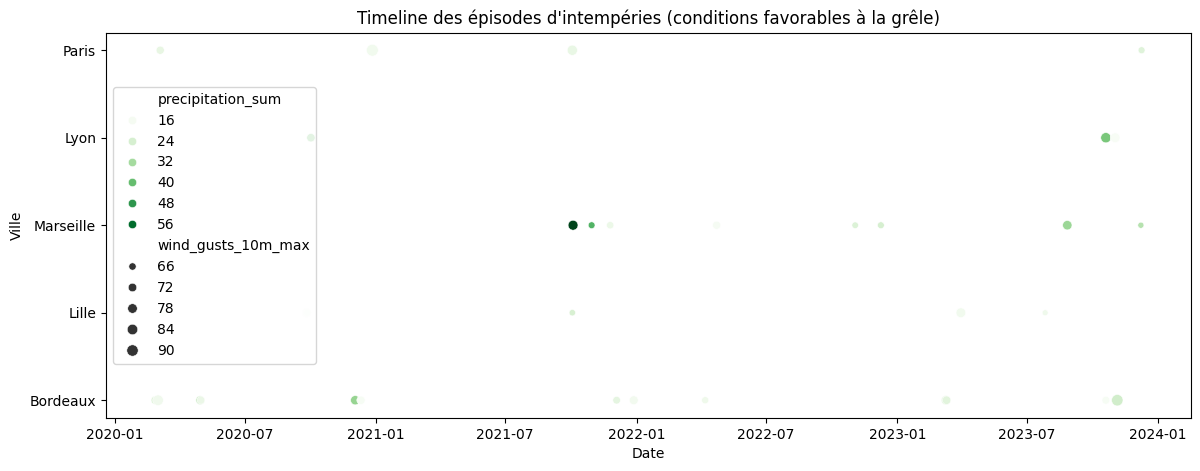

Points affichés : 36


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,5))

sns.scatterplot(
    data=hail_days,
    x="time",
    y="city",
    size="wind_gusts_10m_max",
    hue="precipitation_sum",
    palette="Greens"
)

plt.title("Timeline des épisodes d'intempéries (conditions favorables à la grêle)")
plt.xlabel("Date")
plt.ylabel("Ville")

plt.show()
print("Points affichés :", len(hail_days))

Les épisodes avec risque de grêle sont rares et dispersés dans le temps.

On voit que :

certains événements apparaissent entre 2021 et 2023

ils sont présents dans plusieurs villes

les épisodes les plus marqués ont beaucoup de pluie et de fortes rafales de vent

Donc :

✅ les conditions favorables à la grêle sont liées à des périodes d’orages avec fortes précipitations et vent intense, mais elles restent peu fréquentes.

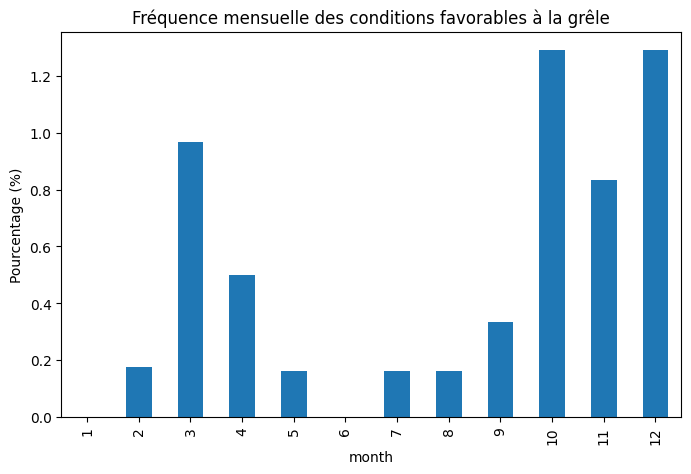

In [31]:
hail_month = weather_data.groupby("month")["hail_risk"].mean() * 100

hail_month.plot(kind="bar", figsize=(8,5))

plt.title("Fréquence mensuelle des conditions favorables à la grêle")
plt.ylabel("Pourcentage (%)")
plt.show()

Les conditions favorables à la grêle sont rares dans l’année.

On voit que :

presque aucun événement en hiver et début été

quelques occurrences au printemps

les mois avec le plus de risque sont octobre et décembre

Donc :

✅ les épisodes d’intempéries restent peu fréquents mais apparaissent davantage à certaines périodes de l’année, quand les conditions météo deviennent plus instables.